## Imports

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from src.models.heston import HestonModel
from src.pricing.heston_pricer import heston_implied_volatility
from src.calibration.optimizers import calibrate_heston_surface

## Parameters

In [2]:
spot = 100.0
rate = 0.03
dividend_yield = 0.0

strikes = np.array([80, 90, 100, 110, 120], dtype=float)
maturities = np.array([0.25, 0.50, 1.00, 2.00], dtype=float)

## Model

In [3]:
true_model = HestonModel(
    kappa=2.0,
    theta=0.04,
    sigma=0.30,
    rho=-0.70,
    v0=0.04,
)

true_model

HestonModel(kappa=2.0, theta=0.04, sigma=0.3, rho=-0.7, v0=0.04)

## generation

In [4]:
market_vol_surface = np.zeros((len(maturities), len(strikes)))

for i, maturity in enumerate(maturities):
    for j, strike in enumerate(strikes):
        market_vol_surface[i, j] = heston_implied_volatility(
            spot=spot,
            strike=strike,
            maturity=maturity,
            rate=rate,
            model=true_model,
            dividend_yield=dividend_yield,
        )

In [5]:
np.random.seed(42)

noise = np.random.normal(
    loc=0.0,
    scale=0.0005,
    size=market_vol_surface.shape,
)

synthetic_market_surface = market_vol_surface + noise

## Surface

In [6]:
surface_df = pd.DataFrame(
    synthetic_market_surface,
    index=[f"T={t}" for t in maturities],
    columns=[f"K={k}" for k in strikes],
)

surface_df

,K=80.0,K=90.0,K=100.0,K=110.0,K=120.0
T=0.25,0.719948,0.490840,0.395232,0.414033,0.624340
T=0.5,0.364958,0.312794,0.277812,0.256971,0.262014
T=1.0,0.226728,0.210530,0.195701,0.180708,0.168655
T=2.0,0.160124,0.147895,0.139299,0.132748,0.129432


## Calibration

In [7]:
calibrated_model = calibrate_heston_surface(
    strikes=strikes,
    maturities=maturities,
    market_vol_surface=synthetic_market_surface,
    spot=spot,
    rate=rate,
    dividend_yield=dividend_yield,
    initial_guess=(1.5, 0.05, 0.25, -0.50, 0.05),
)

calibrated_model

HestonModel(kappa=1.5064985800173296, theta=0.040244492022498135, sigma=0.2792160843123156, rho=-0.6969406955758299, v0=0.03994004105698138)

## Comparison

In [8]:
comparison = pd.DataFrame({
    "parameter": ["kappa", "theta", "sigma", "rho", "v0"],
    "true": [
        true_model.kappa,
        true_model.theta,
        true_model.sigma,
        true_model.rho,
        true_model.v0,
    ],
    "calibrated": [
        calibrated_model.kappa,
        calibrated_model.theta,
        calibrated_model.sigma,
        calibrated_model.rho,
        calibrated_model.v0,
    ],
})

comparison["absolute_error"] = (
    comparison["calibrated"] - comparison["true"]
).abs()

comparison

,parameter,true,calibrated,absolute_error
0,kappa,2.00,1.506499,0.493501
1,theta,0.04,0.040244,0.000244
2,sigma,0.30,0.279216,0.020784
3,rho,-0.70,-0.696941,0.003059
4,v0,0.04,0.039940,0.000060


In [9]:
calibrated_surface = np.zeros_like(synthetic_market_surface)

for i, maturity in enumerate(maturities):
    for j, strike in enumerate(strikes):
        calibrated_surface[i, j] = heston_implied_volatility(
            spot=spot,
            strike=strike,
            maturity=maturity,
            rate=rate,
            model=calibrated_model,
            dividend_yield=dividend_yield,
        )

## Metrics

In [10]:
residuals = calibrated_surface - synthetic_market_surface

rmse = np.sqrt(np.mean(residuals**2))
mae = np.mean(np.abs(residuals))
max_abs_error = np.max(np.abs(residuals))

metrics = pd.DataFrame({
    "metric": ["RMSE", "MAE", "Max Absolute Error"],
    "value": [rmse, mae, max_abs_error],
})

metrics

,metric,value
0,RMSE,0.000777
1,MAE,0.000646
2,Max Absolute Error,0.001506


## Plots

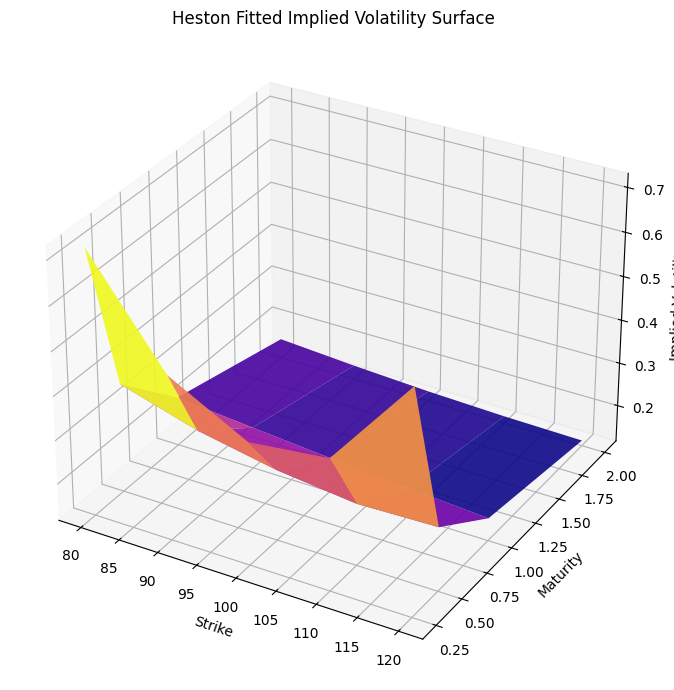

In [20]:
fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection="3d")
K_grid, T_grid = np.meshgrid(strikes, maturities)

ax.plot_surface(
    K_grid,
    T_grid,
    calibrated_surface,
    cmap="plasma",
    edgecolor="none",
    alpha=0.9
)

ax.set_title("Heston Fitted Implied Volatility Surface")
ax.set_xlabel("Strike")
ax.set_ylabel("Maturity")
ax.set_zlabel("Implied Volatility")

plt.tight_layout()
plt.show()

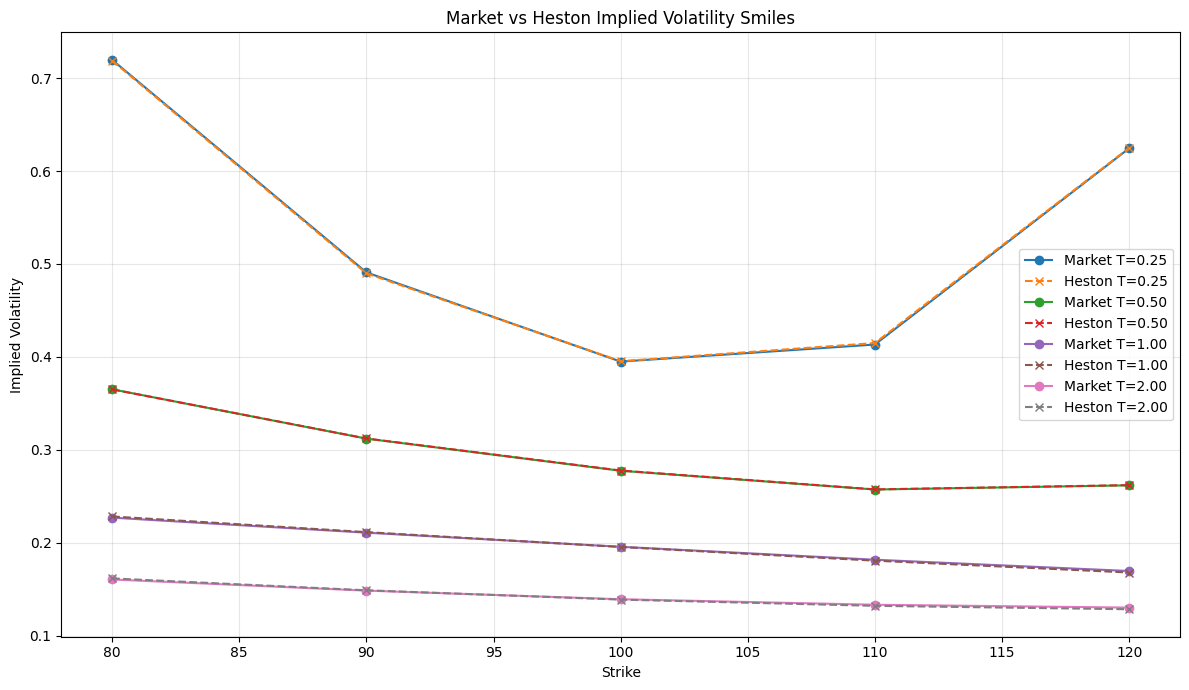

In [17]:
plt.figure(figsize=(12, 7))

for i, maturity in enumerate(maturities):
    plt.plot(
        strikes,
        market_vol_surface[i],
        marker="o",
        linestyle="-",
        label=f"Market T={maturity:.2f}"
    )

    plt.plot(
        strikes,
        calibrated_surface[i],
        marker="x",
        linestyle="--",
        label=f"Heston T={maturity:.2f}"
    )

plt.title("Market vs Heston Implied Volatility Smiles")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

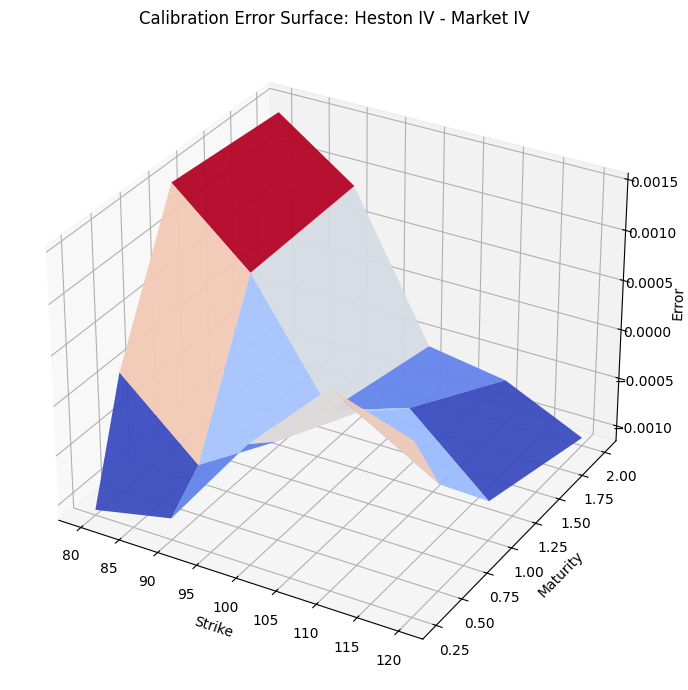

In [19]:
fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection="3d")
K_grid, T_grid = np.meshgrid(strikes, maturities)

ax.plot_surface(
    K_grid,
    T_grid,
    residuals,
    cmap="coolwarm",
    edgecolor="none",
    alpha=0.95
)

ax.set_title("Calibration Error Surface: Heston IV - Market IV")
ax.set_xlabel("Strike")
ax.set_ylabel("Maturity")
ax.set_zlabel("Error")

plt.tight_layout()
plt.show()

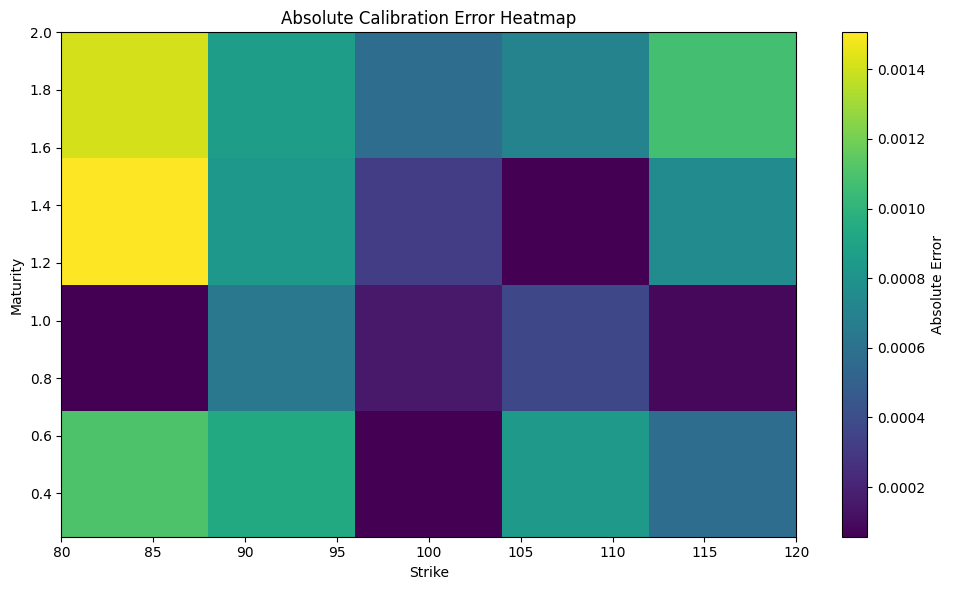

In [21]:
plt.figure(figsize=(10, 6))

plt.imshow(
    np.abs(residuals),
    aspect="auto",
    origin="lower",
    extent=[
        min(strikes),
        max(strikes),
        min(maturities),
        max(maturities)
    ]
)

plt.colorbar(label="Absolute Error")
plt.title("Absolute Calibration Error Heatmap")
plt.xlabel("Strike")
plt.ylabel("Maturity")

plt.tight_layout()
plt.show()

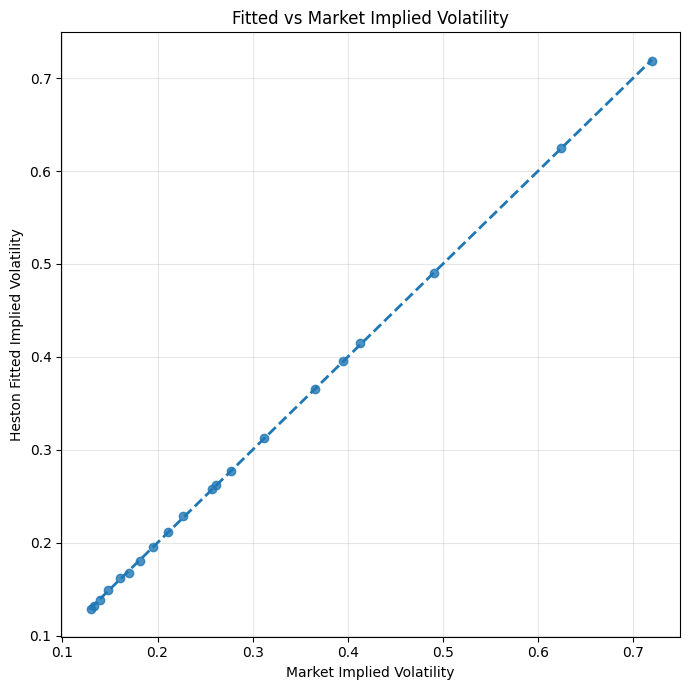

In [22]:
market_flat = market_vol_surface.flatten()
fitted_flat = calibrated_surface.flatten()

plt.figure(figsize=(7, 7))

plt.scatter(market_flat, fitted_flat, alpha=0.8)

min_vol = min(market_flat.min(), fitted_flat.min())
max_vol = max(market_flat.max(), fitted_flat.max())

plt.plot(
    [min_vol, max_vol],
    [min_vol, max_vol],
    linestyle="--",
    linewidth=2
)

plt.title("Fitted vs Market Implied Volatility")
plt.xlabel("Market Implied Volatility")
plt.ylabel("Heston Fitted Implied Volatility")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

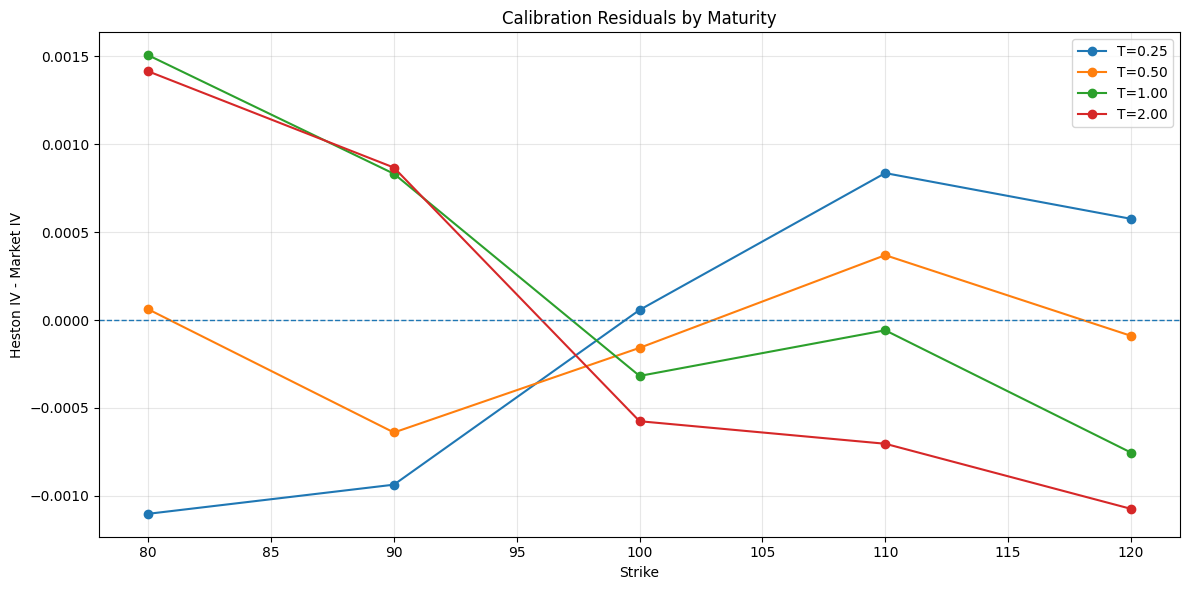

In [23]:
plt.figure(figsize=(12, 6))

for i, maturity in enumerate(maturities):
    plt.plot(
        strikes,
        residuals[i],
        marker="o",
        label=f"T={maturity:.2f}"
    )

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Calibration Residuals by Maturity")
plt.xlabel("Strike")
plt.ylabel("Heston IV - Market IV")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

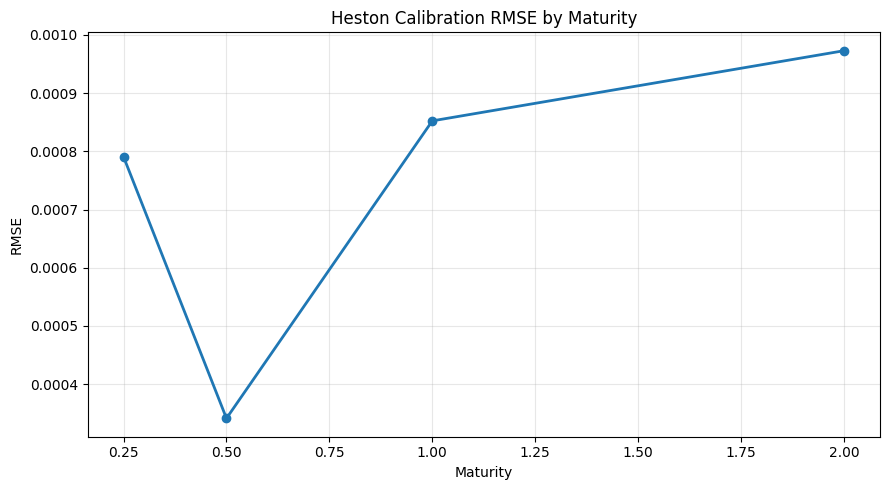

In [25]:
rmse_by_maturity = np.sqrt(np.mean(residuals ** 2, axis=1))

plt.figure(figsize=(9, 5))

plt.plot(
    maturities,
    rmse_by_maturity,
    marker="o",
    linewidth=2
)

plt.title("Heston Calibration RMSE by Maturity")
plt.xlabel("Maturity")
plt.ylabel("RMSE")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Conclusion

This notebook validates the Heston pricing and calibration pipeline on a synthetic implied volatility surface.

A synthetic market surface was generated using known Heston parameters and then perturbed with small Gaussian noise. The calibration procedure was then used to recover the Heston parameters from the noisy implied volatility surface.

The calibrated model reproduces the synthetic volatility surface with low pricing error, validating the Fourier pricing implementation, the Black-Scholes implied volatility conversion, and the calibration objective.

This synthetic experiment is an important validation step before applying the model to real option market data.